In [3]:
import joblib
import os
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from datetime import datetime
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------
# 1️⃣ Cargar modelo existente
# ------------------------------
modelo_path = "sentiment_model_es.pkl"
pipeline_cargado = joblib.load(modelo_path)
print("✅ Modelo cargado desde:", modelo_path)

# Extraemos vectorizador y clasificador
vectorizer = pipeline_cargado.named_steps['tfidf']
model = pipeline_cargado.named_steps['clf']


✅ Modelo cargado desde: sentiment_model_es.pkl


In [7]:
csv_path = "/content/dataset_entrenable_sentimiento_es.csv"
df_nuevo = pd.read_csv(csv_path)


In [8]:
pipeline_actualizado = reentrenar_modelo(pipeline_cargado, df_nuevo)


✅ Modelo reentrenado
Accuracy: 0.861359741001714

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.87      2704
           1       0.86      0.86      0.86      2547

    accuracy                           0.86      5251
   macro avg       0.86      0.86      0.86      5251
weighted avg       0.86      0.86      0.86      5251

Modelo actualizado guardado como: sentiment_model_es_actualizado.pk1


In [9]:
def reentrenar_modelo(pipeline_existente, df_nuevo, test_size=0.2):
    X = df_nuevo['text_clean']
    y = df_nuevo['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Crear un nuevo pipeline (manteniendo configuración robusta)
    pipeline_nuevo = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=5)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])

    pipeline_nuevo.fit(X_train, y_train)

    # Evaluación
    y_pred = pipeline_nuevo.predict(X_test)
    print("✅ Modelo reentrenado")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Guardar pipeline actualizado
    nuevo_modelo_path = "sentiment_model_es_actualizado.pk1"
    joblib.dump(pipeline_nuevo, nuevo_modelo_path)
    print("Modelo actualizado guardado como:", nuevo_modelo_path)

    return pipeline_nuevo


In [10]:
DATASET_FEEDBACK = "consultas_recolectadas.csv"

def predecir_y_guardar(pipeline, texto):
    if not texto.strip():
        return "⚠️ Por favor escribe algo"

    pred_proba = pipeline.predict_proba([texto])[0][1]
    etiqueta = 1 if pred_proba > 0.5 else 0

    # Guardar en CSV de feedback
    nuevo_dato = pd.DataFrame([[texto, etiqueta, datetime.now()]], columns=['text_clean', 'label', 'fecha_recoleccion'])
    header = not os.path.exists(DATASET_FEEDBACK)
    nuevo_dato.to_csv(DATASET_FEEDBACK, mode='a', header=header, index=False)

    return {"POSITIVO": pred_proba, "NEGATIVO": 1-pred_proba}, f"Etiqueta predicha: {'POSITIVO' if etiqueta==1 else 'NEGATIVO'}"


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar tu CSV de entrenamiento/reentrenamiento
csv_path = "dataset_entrenable_sentimiento_es.csv"
df = pd.read_csv(csv_path)

# Columnas de texto y etiqueta
X = df['text_clean']
y = df['label']

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Conjunto de prueba preparado. Filas de prueba:", len(X_test))

✅ Conjunto de prueba preparado. Filas de prueba: 5251


Accuracy: 0.861359741001714
              precision    recall  f1-score   support

    NEGATIVO       0.87      0.86      0.87      2704
    POSITIVO       0.86      0.86      0.86      2547

    accuracy                           0.86      5251
   macro avg       0.86      0.86      0.86      5251
weighted avg       0.86      0.86      0.86      5251



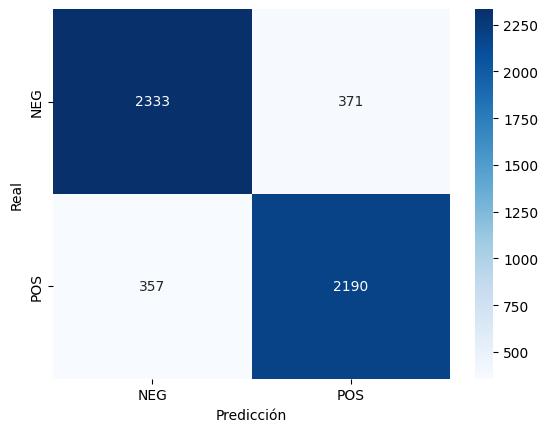

In [12]:
# Predecir con el pipeline cargado
y_pred = pipeline_actualizado.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Reporte completo
print(classification_report(y_test, y_pred, target_names=["NEGATIVO", "POSITIVO"]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["NEG", "POS"], yticklabels=["NEG", "POS"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()